# JJ current-current correlator -- MASSLESS valence (single ensemble)

Load-only **combiner** notebook for ONE ensemble at MASSLESS valence ($m_F=m_P=0$).  The heavy work
(inversions, disc post-processing, later reweighting $R$) is done by the run script; here we only
**load** the produced `corr_*.h5` (connected + raw disc traces) and `disc_proced.*.h5` (disc two-point),
jackknife, and combine.  Procedure reference: `jj_analysis_global_procedure_claude.md`.

Independent blocks: **conn tp / sp / ylm** (each = vector `Vpp/Vmm` + axial `Apm`), **disc** (vector only),
**sum** ($-\mathrm{conn}+\mathrm{disc}$, Eq. 3.39).  Free massless is validated against the analytical
expressions of arXiv:2510.03085 (overlay TODO in the sum block).  Separate notebooks exist for $m_F$ / $m_P$;
cross-mass comparison is a separate export/read notebook.

In [1]:
import h5py
import os
import glob
import math
import numpy as np
import matplotlib.pyplot as plt
from natsort import natsorted

In [2]:
# ---- jackknife (resampling over the LAST stat axis = configs) ----
class Jackknife:
    def __init__(self, len_data, binsize):
        self.binsize = binsize
        self.nbins = math.floor(len_data / self.binsize)
        self.N = self.binsize * self.nbins
        self.jack_avg = []
        self.est = 0
        self.var_est = 0
    def set(self, func, list_of_data):
        for i in range(self.nbins):
            self.jack_avg.append(func(i, self.binsize, list_of_data))
    def do_it(self):
        for i in range(self.nbins): self.est += self.jack_avg[i]
        self.est /= self.nbins
        for i in range(self.nbins): self.var_est += (self.jack_avg[i] - self.est) ** 2
        self.var_est /= self.nbins
        self.var_est *= self.nbins - 1
    def mean(self): return self.est
    def err(self):  return np.sqrt(self.var_est)

def simple_mean(i, binsize, np_data):
    return np.mean(np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0), axis=0)

## Block 0 -- ensemble id + load (the START)

Set the ensemble (`ens`: `'free'` for the U=1 check, or an interacting `--ens-dir` basename) and the
MASSLESS valence.  The notebook ASSERTS the designated mass pattern.

In [3]:
# ===== Block 0: ENSEMBLE ID + parameters (MASSLESS) =====
gsq = "8.000000"; at = "0.200000"; Nt = 128; L = 1; Nf = 2; nu0 = "1.000000"
current = "vector"

# free vs interacting: 'free' (U=1 check) or the --ens-dir basename of an interacting ensemble.
ens = 'free'

# Valence mass for THIS notebook = MASSLESS.  Assert the designated pattern.
mre, mim = 0.0, 0.0
assert (mre == 0.0) and (mim == 0.0), "MASSLESS notebook: require (mre,mim)==(0,0)."
parity = False   # massless: Vmm = conj(Vpp); axial uses massless D_ov on both legs

n_t0 = 2          # match --n-t0 used in the run
nhits = 64        # match --nhits (free --all run used 64)
binsize = 1
dir1 = '/mnt/barracuda22/qed3/qed3/src/both_3d/'

# ---- resampling unit (the jackknife statistical sample) ----
# FREE (ens=='free'): the gauge field is fixed (U=1), so the stochastic HITS are the ensemble ->
#   resample over hits (averaging only the correlated t0 origins within a hit).
# INTERACTING: each gauge CONFIG is an independent sample; hits are correlated noise on a shared
#   background -> average over (h,t0) per config and resample over configs.
resample = 'hits' if ens == 'free' else 'configs'   # override here if needed

def esnid():    return ens + '_vmRe%.6fvmIm%.6f' % (mre, mim)
def corr_dir(): return dir1 + 'data_' + esnid() + '/corr_nt0%d_nhits%d/' % (n_t0, nhits)
xxx = float(at) * np.arange(Nt)

print('ensemble id (esnid) =', esnid(), '(free U=1)' if ens == 'free' else '(interacting)')
print('corr dir            =', corr_dir())
print('resample over       =', resample, '(free=>hits, interacting=>configs)')

ensemble id (esnid) = free_vmRe0.000000vmIm0.000000 (free U=1)
corr dir            = /mnt/barracuda22/qed3/qed3/src/both_3d/data_free_vmRe0.000000vmIm0.000000/corr_nt02_nhits64/
resample over       = hits (free=>hits, interacting=>configs)


In [4]:
# ===== loaders (LOAD-ONLY).  corr_*.h5 = conn + raw disc J; disc_proced.*.h5 = disc two-point. =====
# The jackknife SAMPLE axis follows `resample` (block 0): 'hits' -> one sample per hit (t0-averaged,
# config fixed; free); 'configs' -> one sample per config ((h,t0)-averaged; interacting).
def _hits(f):
    return natsorted(k for k in f.keys() if k.startswith('h') and k[1:].isdigit())

def _t0s(f, hk):
    return natsorted(k for k in f[hk].keys() if k.startswith('t0_'))

def _complete(f):   # jj_corr / jj_disc_postproc 'complete' sentinel (written LAST)
    return 'complete' in f

def load_conn(leaf):
    '''(nsamp, Nt) complex.  leaf e.g. "tp/Vpp", "sp/Vmm", "axial/tp/Apm".
       resample='hits': one t0-averaged row per HIT; 'configs': one (h,t0)-averaged row per config.'''
    samp = []
    def get(hk, tk):
        k = '%s/%s/%s' % (hk, tk, leaf)
        return (f[k + '/real'][:] + 1j*f[k + '/imag'][:]) if (k + '/real') in f else None
    for fn in natsorted(glob.glob(corr_dir() + 'corr.*.h5')):
        with h5py.File(fn, 'r') as f:
            if not _complete(f): continue
            if resample == 'hits':
                for hk in _hits(f):
                    a = [g for tk in _t0s(f, hk) if (g := get(hk, tk)) is not None]
                    if a: samp.append(np.mean(a, axis=0))
            else:
                a = [g for hk in _hits(f) for tk in _t0s(f, hk) if (g := get(hk, tk)) is not None]
                if a: samp.append(np.mean(a, axis=0))
    return np.array(samp)

def load_ylm_conn(ch='Vpp'):
    '''(nsamp, n_ell, Nt) complex + ls, with the same resample sampling as load_conn.'''
    samp, ls = [], None
    for fn in natsorted(glob.glob(corr_dir() + 'corr.*.h5')):
        with h5py.File(fn, 'r') as f:
            if not _complete(f) or 'ls' not in f: continue
            ls = f['ls'][:]
            def tower(pairs):
                G = np.zeros((len(ls), Nt), dtype=complex)
                for (hk, tk) in pairs:
                    for li, l in enumerate(ls):
                        k = '%s/%s/ylm/%s/l%d/' % (hk, tk, ch, l)
                        G[li] += f[k + 'real'][:] + 1j*f[k + 'imag'][:]
                return G / len(pairs)
            if resample == 'hits':
                for hk in _hits(f):
                    samp.append(tower([(hk, tk) for tk in _t0s(f, hk)]))
            else:
                samp.append(tower([(hk, tk) for hk in _hits(f) for tk in _t0s(f, hk)]))
    return np.array(samp), ls

def load_rawJ(leaf):
    '''(nsamp, Nt) complex: RAW disc single-current trace h{h}/disc/<leaf>.
       resample='hits': one sample per hit; 'configs': h-averaged per config.  leaf e.g. "tp/J".'''
    samp = []
    for fn in natsorted(glob.glob(corr_dir() + 'corr.*.h5')):
        with h5py.File(fn, 'r') as f:
            if not _complete(f): continue
            def get(hk):
                k = '%s/disc/%s' % (hk, leaf)
                return (f[k + '/real'][:] + 1j*f[k + '/imag'][:]) if (k + '/real') in f else None
            if resample == 'hits':
                for hk in _hits(f):
                    g = get(hk)
                    if g is not None: samp.append(g)
            else:
                a = [g for hk in _hits(f) if (g := get(hk)) is not None]
                if a: samp.append(np.mean(a, axis=0))
    return np.array(samp)

def load_dp(leaf):
    '''(nconf, Nt) complex: per complete disc_proced.<k>.h5, the top-level disc two-point `leaf`
       (e.g. "tp/Vpp", "ylm/Vpp/l1").  NOTE: disc_proced is already hit-collapsed -> ONE row per
       config (no hit resampling); for FREE (1 config) this is a single sample (central value only,
       no jackknife error).  For free-disc errors, resample the raw J(t) over hits (see Block disc).'''
    data = []
    for fn in natsorted(glob.glob(corr_dir() + 'disc_proced.*.h5')):
        with h5py.File(fn, 'r') as f:
            if not _complete(f): continue
            if leaf + '/real' in f:
                data.append(f[leaf + '/real'][:] + 1j*f[leaf + '/imag'][:])
    return np.array(data)

In [5]:
# ---- jackknife + SIGNED log-axis plotters (no abs; +y solid/blue, -y dashed/red) ----
YLIM = (1e-11, 1e-1)

def jk_of(arr):
    jk = Jackknife(arr.shape[0], binsize); jk.set(simple_mean, arr); jk.do_it(); return jk

def ebar_pm(ax, x, y, e, label, cp='C0', cm='C3'):
    ax.errorbar(x,  y, e, ls='solid', capsize=2.0, color=cp, label='+' + label)
    ax.errorbar(x, -y, e, ls='--',    capsize=2.0, color=cm, label='-' + label)

def plot_signed(ax, arr, label):
    '''Draw a (nsamp,Nt) REAL array signed on a log axis.  >=2 samples -> jackknife errors;
       <2 samples -> central value only (no error bars).  Returns nsamp.'''
    if arr.size == 0:
        ax.set_title('(no data) ' + label); return 0
    n = arr.shape[0]
    if n < 2:
        y = np.mean(arr, axis=0)
        ax.plot(xxx,  y, ls='solid', color='C0', label='+' + label)
        ax.plot(xxx, -y, ls='--',    color='C3', label='-' + label + ' (1 sample, no err)')
    else:
        jk = jk_of(arr); ebar_pm(ax, xxx, jk.mean(), jk.err(), label)
    ax.set_yscale('log'); ax.set_ylim(YLIM); ax.set_xlabel('$t$ (a.u.)'); ax.legend(fontsize=8)
    return n

# ---- t-folding (VECTOR channel only) ----
# The vector correlator is reflection-even in dt: g(dt)=g(Nt-dt) (trace cyclicity + translation).
# Folding dt with Nt-dt averages the two equal halves -> ~sqrt(2) smaller errors.  Massless: the Im part
# is pure noise (gauge-averaged Im is exactly zero), so we fold the REAL part only and omit Im.
# (Axial C_{A+-} is NOT self-even -- it reflects to C_{A-+} (Eq. 3.57) -- so it is NOT folded.)
def tfold(arr):
    '''(nsamp,Nt) -> (nsamp, Nt//2+1): out[tau]=(arr[tau]+arr[(Nt-tau)%Nt])/2, tau=0..Nt//2.'''
    nh = Nt // 2
    idx = (Nt - np.arange(nh + 1)) % Nt
    return 0.5 * (arr[:, :nh + 1] + arr[:, idx])

xxx_fold = float(at) * np.arange(Nt // 2 + 1)

def plot_signed_fold(ax, arr_real, label):
    '''Fold a (nsamp,Nt) REAL array in t, jackknife, draw signed on a log axis (vector channel).'''
    if arr_real.size == 0:
        ax.set_title('(no data) ' + label); return 0
    f = tfold(arr_real); n = f.shape[0]
    if n < 2:
        y = np.mean(f, axis=0)
        ax.plot(xxx_fold,  y, ls='solid', color='C0', label='+' + label)
        ax.plot(xxx_fold, -y, ls='--',    color='C3', label='-' + label + ' (1 sample, no err)')
    else:
        jk = jk_of(f); ebar_pm(ax, xxx_fold, jk.mean(), jk.err(), label)
    ax.set_yscale('log'); ax.set_ylim(YLIM); ax.set_xlabel('$t$ (a.u.)'); ax.legend(fontsize=8)
    return n

In [6]:
# ---- completeness report for THIS ensemble (load-only sanity) ----
cf = natsorted(glob.glob(corr_dir() + 'corr.*.h5'))
df = natsorted(glob.glob(corr_dir() + 'disc_proced.*.h5'))
def n_complete(files):
    n = 0
    for fn in files:
        try:
            with h5py.File(fn, 'r') as f:
                if 'complete' in f: n += 1
        except OSError: pass
    return n
print('corr.*.h5        : %3d found, %3d complete' % (len(cf), n_complete(cf)))
print('disc_proced.*.h5 : %3d found, %3d complete   (0 => run jj_disc_postproc; disc/sum blocks need these)'
      % (len(df), n_complete(df)))

corr.*.h5        :   1 found,   1 complete
disc_proced.*.h5 :   1 found,   1 complete   (0 => run jj_disc_postproc; disc/sum blocks need these)


## Block tp -- connected (vector t-folded + axial)

Temporal projection.  CFT (Eq. 4.31): the vector temporal correlator is **negative**, $\mathrm{Re}\,G_t<0$
(the dashed $-$ branch is visible).  **Vector is t-folded** ($g(\Delta t)=g(N_t-\Delta t)$, reflection-even
by cyclicity) and uses **Re only** (massless $\Rightarrow$ $\mathrm{Im}$ is pure noise, omitted; the
$\mathrm{Vmm}=\mathrm{conj}(\mathrm{Vpp})$ round-trip and $\langle\mathrm{Im}\rangle\!\approx\!0$ are printed
as checks).  **Axial $C_{A+-}$ is NOT folded** (it reflects to $C_{A-+}$, Eq. 3.57).

tp  max|Vmm-conj(Vpp)| = 0.0  ;  max|<Im Vpp>| = 0.00015237918977073218 (massless: ~0, omitted)


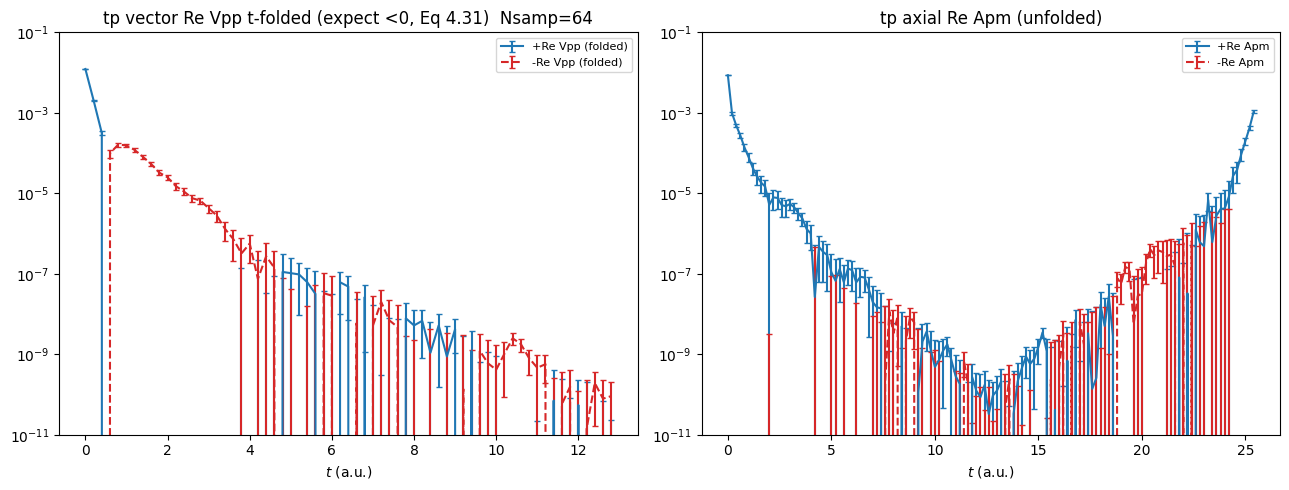

In [7]:
# ===== Block tp: VECTOR (t-folded Re; massless => Im is pure noise, OMITTED) + axial (unfolded) =====
tp_vpp = load_conn('tp/Vpp'); tp_vmm = load_conn('tp/Vmm'); tp_apm = load_conn('axial/tp/Apm')
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
nc = plot_signed_fold(ax[0], tp_vpp.real, 'Re Vpp (folded)')
ax[0].set_title('tp vector Re Vpp t-folded (expect <0, Eq 4.31)  Nsamp=%d' % nc)
# axial C_{A+-} is NOT self-reflection-even (reflects to C_{A-+}, Eq 3.57) -> NOT folded; signed Re
plot_signed(ax[1], tp_apm.real, 'Re Apm')
ax[1].set_title('tp axial Re Apm (unfolded)')
plt.tight_layout()
# consistency (massless): Vmm = conj(Vpp) round-trip, and Im is pure noise (omitted from the plots)
if tp_vpp.size and tp_vmm.size:
    print('tp  max|Vmm-conj(Vpp)| =', np.max(np.abs(np.mean(tp_vmm, 0) - np.conj(np.mean(tp_vpp, 0)))),
          ' ;  max|<Im Vpp>| =', np.max(np.abs(np.mean(tp_vpp.imag, 0))), '(massless: ~0, omitted)')

## Block sp -- connected (vector t-folded + axial)

Spatial projection.  CFT (Eq. 4.28): the vector spatial correlator is **positive**, $\mathrm{Re}\,G_s>0$
(the $+$ branch visible) -- opposite sign to tp, the clean control.  **Vector t-folded, Re only**
(Im omitted); axial unfolded.

sp  max|<Im Vpp>| = 0.00018396662249766204 (massless: ~0, omitted)


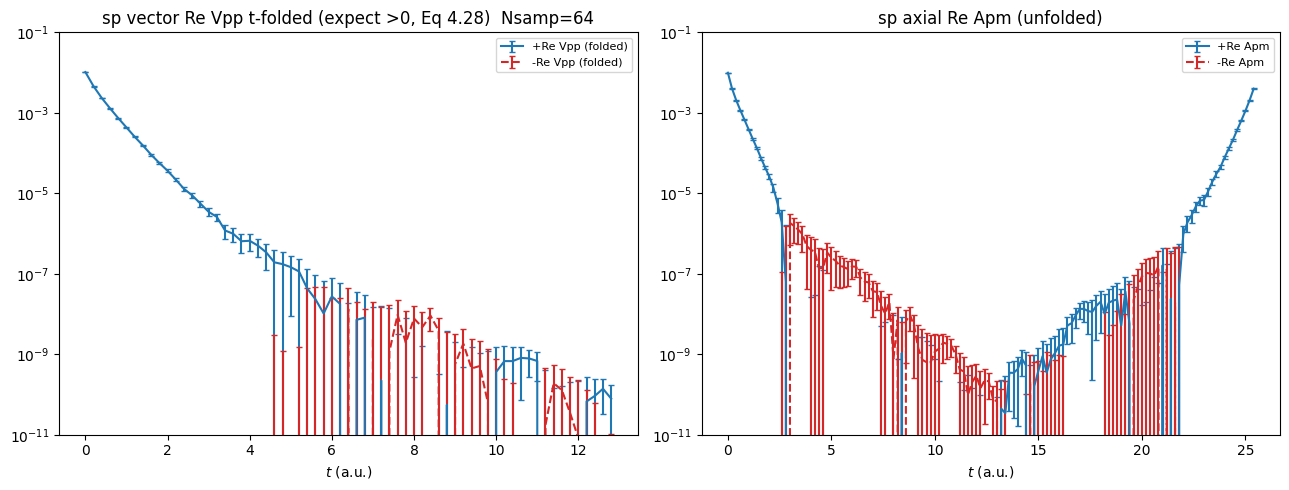

In [8]:
# ===== Block sp: VECTOR (t-folded Re; Im OMITTED) + axial (unfolded) =====
sp_vpp = load_conn('sp/Vpp'); sp_vmm = load_conn('sp/Vmm'); sp_apm = load_conn('axial/sp/Apm')
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
nc = plot_signed_fold(ax[0], sp_vpp.real, 'Re Vpp (folded)')
ax[0].set_title('sp vector Re Vpp t-folded (expect >0, Eq 4.28)  Nsamp=%d' % nc)
plot_signed(ax[1], sp_apm.real, 'Re Apm')
ax[1].set_title('sp axial Re Apm (unfolded)')
plt.tight_layout()
if sp_vpp.size:
    print('sp  max|<Im Vpp>| =', np.max(np.abs(np.mean(sp_vpp.imag, 0))), '(massless: ~0, omitted)')

## Block ylm -- connected (vector tower, m-summed, t-folded)

Spherical-harmonic tower $\ell=0,1,2$, each in its **own panel**.  CFT (Eqs. 4.34-4.35): $\ell=0\approx0$
(charge conservation), $\ell=1\sim-e^{-2t}$, $\ell=2\sim-e^{-3t}$.  Each panel is **signed**:
$+\mathrm{Re}$ blue solid, $-\mathrm{Re}$ red dashed -- for $\ell\ge1$ the $-$Re (red) branch is the visible
(positive) one.  **t-folded, Re only** (Im omitted, massless).

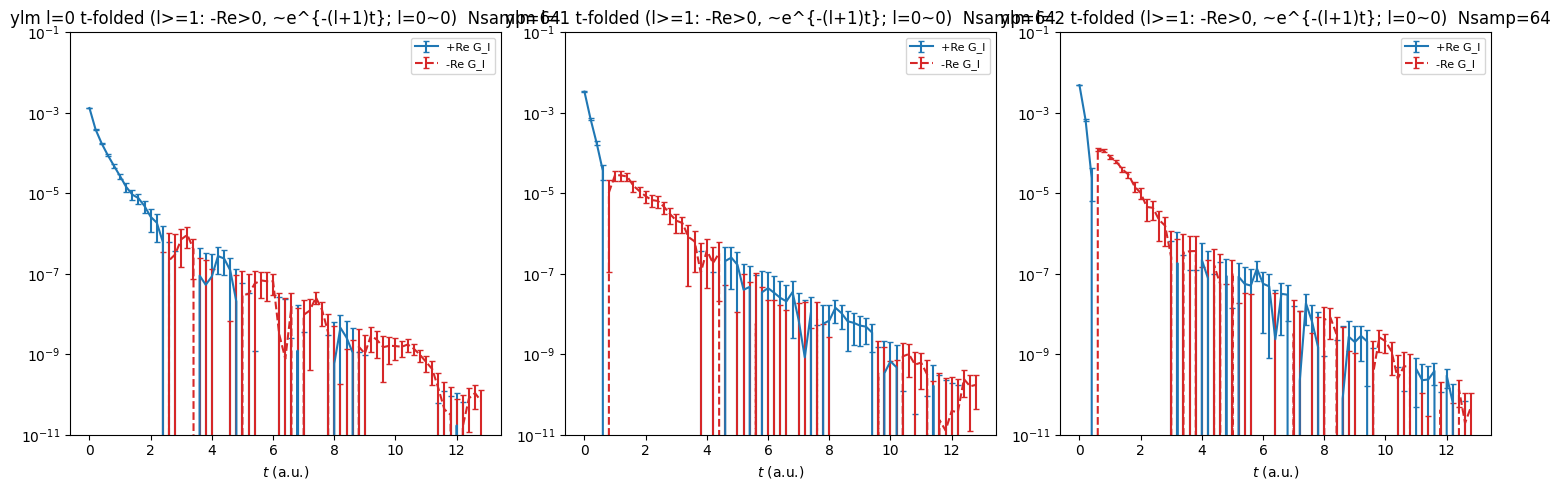

In [9]:
# ===== Block ylm: VECTOR tower (t-folded Re; Im OMITTED) -- l=0,1,2 SEPARATED, +/- colored =====
ylm_vpp, ylm_ls = load_ylm_conn('Vpp')
if ylm_vpp.size:
    nl = len(ylm_ls)
    fig, ax = plt.subplots(1, nl, figsize=(5*nl, 5), squeeze=False); ax = ax[0]
    for li, l in enumerate(ylm_ls):
        jp = jk_of(tfold(ylm_vpp[:, li, :].real))
        ebar_pm(ax[li], xxx_fold, jp.mean(), jp.err(), 'Re G_l')   # + blue solid (C0), - red dashed (C3)
        ax[li].set_yscale('log'); ax[li].set_ylim(YLIM); ax[li].set_xlabel('$t$ (a.u.)'); ax[li].legend(fontsize=8)
        ax[li].set_title('ylm l=%d t-folded (l>=1: -Re>0, ~e^{-(l+1)t}; l=0~0)  Nsamp=%d' % (l, ylm_vpp.shape[0]))
    plt.tight_layout()
else:
    fig, ax = plt.subplots(1, 1, figsize=(8, 5)); ax.set_title('(no ylm data)')

## Block disc -- disconnected (VECTOR ONLY)

The disc two-point $C^P_\mathrm{disc}(\Delta t)=\bar J(0)\bar J(t)$ from `disc_proced.*.h5`
(produced by `jj_disc_postproc`).  Also shows the RAW single-current trace $J(t)$ from the `corr` file
(keys `h{h}/disc/...`) for inspection.  Axial has no disc.

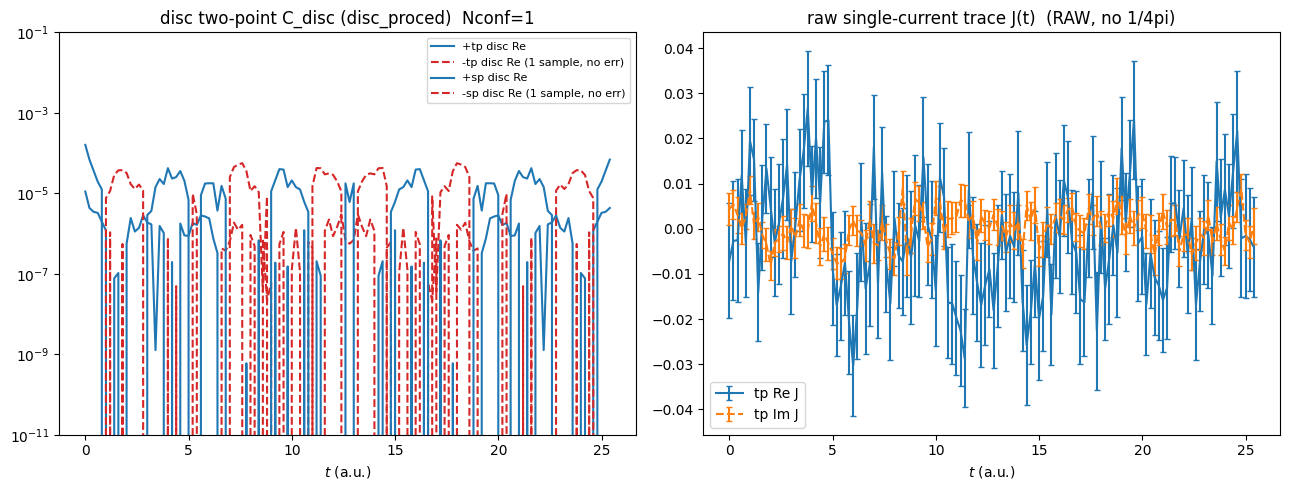

In [10]:
# ===== Block disc: disc two-point (disc_proced) + raw single-current trace J(t) =====
disc_tp = load_dp('tp/Vpp'); disc_sp = load_dp('sp/Vpp')
rawJ_tp = load_rawJ('tp/J'); rawJ_sp = load_rawJ('sp/J')
ls_for_disc = ylm_ls if ylm_ls is not None else np.array([0, 1, 2])
disc_ylm = [load_dp('ylm/Vpp/l%d' % l) for l in ls_for_disc]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
plot_signed(ax[0], disc_tp.real, 'tp disc Re')
plot_signed(ax[0], disc_sp.real, 'sp disc Re')
ax[0].set_title('disc two-point C_disc (disc_proced)  Nconf=%d' % (disc_tp.shape[0] if disc_tp.size else 0))
if rawJ_tp.size:
    jr = jk_of(rawJ_tp.real); ji = jk_of(rawJ_tp.imag)
    ax[1].errorbar(xxx, jr.mean(), jr.err(), capsize=2, label='tp Re J')
    ax[1].errorbar(xxx, ji.mean(), ji.err(), capsize=2, ls='--', label='tp Im J')
    ax[1].legend()
ax[1].set_xlabel('$t$ (a.u.)'); ax[1].set_title('raw single-current trace J(t)  (RAW, no 1/4pi)')
plt.tight_layout()

## Block sum -- physical correlator $-\mathrm{conn}+\mathrm{disc}$

PDF Eq. 3.39: $\frac{2}{N_f}\langle JJ\rangle = -C_\mathrm{conn}+C_\mathrm{disc}$ (bare-$C$; reweighting
$R$ multiplies later).  Vector only (axial = connected-only).  Combined per config (aligned by index).
Free massless: overlay the arXiv:2510.03085 analytical curves here (TODO).

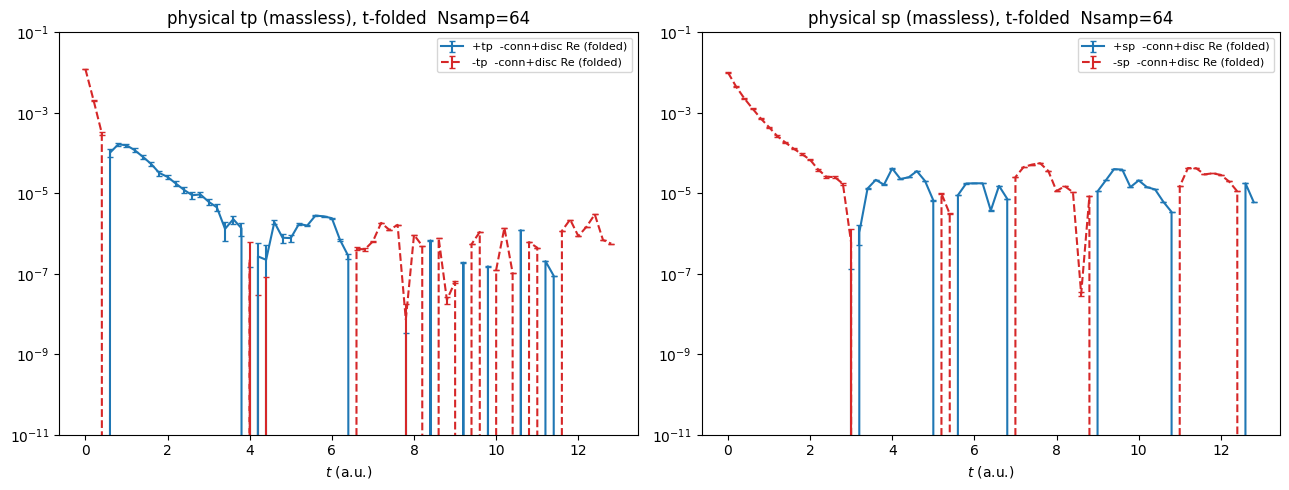

In [11]:
# ===== Block sum: physical = -conn + disc (vector), t-folded Re (Im omitted) =====
# Eq. 3.39: physical = -C_conn + C_disc (bare-C; reweighting R later).  Axial = connected-only.
# Sample-axis bookkeeping:
#   interacting (conn & disc both per-config, equal counts): combine per config -> jackknife configs.
#   free (conn = hit samples, disc_proced = 1 collapsed config): add the disc CENTRAL as a small fixed
#     correction and jackknife over the conn hit-samples.
def physical(conn, disc):
    if conn.size == 0:
        return np.array([])
    if disc.size and disc.shape[0] == conn.shape[0]:
        return -conn + disc                      # aligned per sample (interacting: per config)
    dc = np.mean(disc, axis=0) if disc.size else 0.0
    return -conn + dc                            # free: -conn(hit samples) + disc central

ph_tp = physical(tp_vpp, disc_tp)
ph_sp = physical(sp_vpp, disc_sp)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
n_tp = plot_signed_fold(ax[0], ph_tp.real, 'tp  -conn+disc Re (folded)')
n_sp = plot_signed_fold(ax[1], ph_sp.real, 'sp  -conn+disc Re (folded)')
ax[0].set_title('physical tp (massless), t-folded  Nsamp=%d' % n_tp)
ax[1].set_title('physical sp (massless), t-folded  Nsamp=%d' % n_sp)
plt.tight_layout()

# TODO: overlay arXiv:2510.03085 analytical massless curves (free-field validation).
if ph_tp.size == 0:
    print('NOTE: sum needs conn (corr_*.h5); disc central from disc_proced.*.h5 (run jj_disc_postproc).')